# Bootstrapping

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Der Standardfehler ist die Standardabweichung der Stichprobe geteilt durch die Wurzel der Anzahl der Beobachtungen.

Wenn die Anzahl der Beobachtungen klein ($n\leq 30$) und die zugrundeliegende Verteilung fern von normal ist, dann ist der Standardfehler manchmal kein gutes Mass für den Fehler der Schätzung des Erwartungswerts.

Weiter ist es bei anderen Statistiken (z.B. Median, Varianz, Quantile, Korrelationskoeffizienten) nicht immer analytisch möglich, den Standardfehler zu bestimmen.

Eine Alternative bietet das **Bootstrapping**: Dabei zieht man wiederholt Stichproben mit Zurücklegen aus den Daten und berechnet für jede dieser Stichproben die Statistik, deren Fehler zu bestimmen ist. Die Standardabweichung über diese Schätzungen ist ein guter Indikator für den Fehler der ursprünglichen Statistik.



## 1. Messdaten simulieren

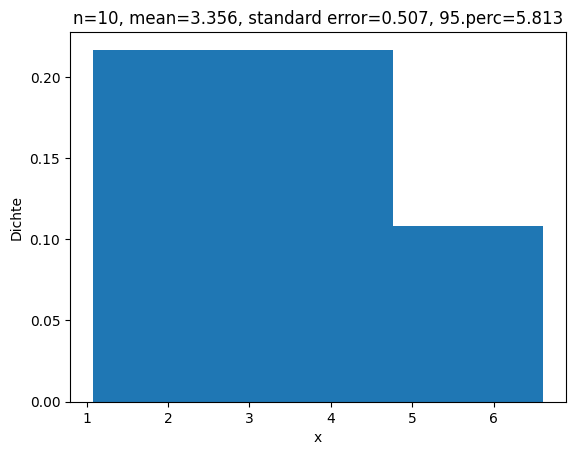

In [2]:
rng = np.random.default_rng()

n_data = 10
data = rng.gamma(1, 1, n_data)
data = rng.triangular(0, 0.5, 7, n_data)
# data = np.array([0.1, 0.2, 0.15, 0.25, 0.11, 0.08, 0.31])

data_mean = np.mean(data)
data_std = np.std(data)
data_se = data_std / np.sqrt(n_data)
data_95perc = np.percentile(data, 95)

plt.hist(data, bins="fd", density=True)
plt.xlabel("x")
plt.ylabel("Dichte")
plt.title(
    f"n={len(data)}, mean={data_mean:.3f}, standard error={data_se:.3f}, 95.perc={data_95perc:.3f}"
)
plt.show()

## 2. Bootstrapping

In [3]:
# Anzahl Subsamples sollte sehr gross sein
n_subsamples = 10_000
# Anzahl Samples pro Subsample sollte gleich der Anzahl Beobachtungen sein
subsample_size = len(data)

rng = np.random.default_rng()
subsamples = rng.choice(data, (n_subsamples, subsample_size), replace=True)
subsamples.shape

(10000, 10)

## 3. Fehler des Mittelwerts schätzen

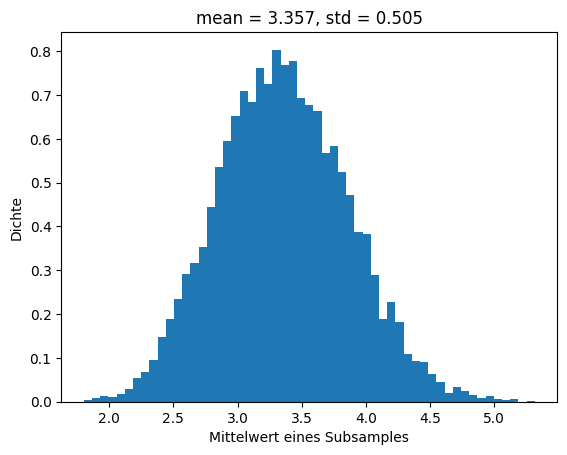

In [4]:
# Für jedes Subsample (Zeile) den Mittelwert berechnen
means = subsamples.mean(axis=1)

means_mean = means.mean()
means_std = means.std()

plt.hist(means, bins="fd", density=True)
plt.xlabel("Mittelwert eines Subsamples")
plt.ylabel("Dichte")
plt.title(f"mean = {means_mean:.3f}, std = {means_std:.3f}")
plt.show()

Die Standardabweichung der Mittelwerte aller Subsamples `means_std` ist nun eine gute Schätzung für den Standardfehler des Mittelwerts der Originalstichprobe. Im Fall des Mittelwerts ist allerdings die Formel $SE = \sigma/\sqrt{n}$ in den meisten Fällen bereits eine sehr gute Schätzung für den Standardfehler.

## 3. Bootstrapping für das 95. Perzentil

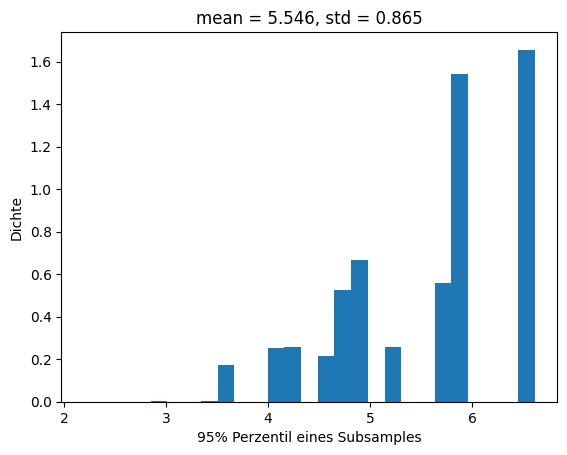

In [5]:
# Für jedes Subsample (Zeile) das 95. Perzentil berechnen
percentiles = np.percentile(subsamples, 95, axis=1)

percentiles_mean = percentiles.mean()
percentiles_std = percentiles.std()

plt.hist(percentiles, bins="fd", density=True)
plt.xlabel("95% Perzentil eines Subsamples")
plt.ylabel("Dichte")
plt.title(f"mean = {percentiles_mean:.3f}, std = {percentiles_std:.3f}")
plt.show()

Hier liefert das Bootstrapping mit der Standardabweichung über die Subsamples `percentiles_std` eine Schätzung des Fehlers des 95. Perzentils der Originalstichprobe. Das Bootstrapping ist hier besonders nützlich, weil es keine Annahmen über die zugrundeliegende Verteilung macht.